# Feature Taxonomy: 1D-Linear vs Multi-D-Linear vs Genuinely Nonlinear

Connecting our autoencoder phase diagram to the Tegmark/Anthropic feature taxonomy.

## The landscape

Recent work has fractured the assumption that "features = directions":

| Regime | Geometry | Composition | Extraction method | Key paper |
|--------|----------|-------------|-------------------|-----------|
| **1D linear** | Single direction per feature | Additive + scaling | Standard SAEs | Elhage et al. Toy Models; Cunningham et al. |
| **Multi-D linear** | k-dim subspace, still additive | Additive + scaling | Subspace SAEs, MFA | Engels et al. (Tegmark) circular features; **Shafran et al. "Directions to Regions"** |
| **Genuinely nonlinear** | Curved manifold | Composition ≠ addition | Nonlinear AEs, diffusion models | **Luo et al. generative meta-model**; SpaDE (Hindupur et al.) |

### Key references

1. **Circuits Updates July 2024** — Distinguishes "1D linear" (features = directions) from "mathematically linear" (composition-as-addition + intensity-as-scaling). The latter admits multi-D features. Anthropic argues mathematical linearity is the deeper property.

2. **Engels et al. "Not All Language Model Features Are One-Dimensionally Linear" (ICLR 2025)** — Finds irreducible 2D circular features (days-of-week, months) in GPT-2/Mistral. Uses SAEs to discover them, then shows they're computationally necessary for modular arithmetic.

3. **Shafran et al. "From Directions to Regions" (arXiv 2602.02464)** — Replaces SAE directions with Mixture of Factor Analyzers (MFA): models activation space as a collection of Gaussian regions with local covariance. Captures nonlinear/multi-D structure that SAEs miss. Outperforms SAEs on steering in Llama-3.1-8B and Gemma-2-2B.

4. **Luo et al. "Learning a Generative Meta-Model of LLM Activations" (arXiv 2602.06964)** — Trains diffusion models on 1B residual stream activations. No structural assumptions (unlike SAE sparsity or MFA Gaussianity). Diffusion loss predicts downstream utility; neurons increasingly isolate concepts as loss decreases.

5. **Hindupur et al. "Projecting Assumptions: SpaDE" (NeurIPS 2025)** — Shows SAE architecture determines what concepts you can find. Standard SAEs are blind to heterogeneous intrinsic dimensionality and nonlinear separability. SpaDE uses flexible receptive fields.

6. **Engels & Michaud "Feature Manifold Scaling"** — SAEs tile multi-D features with many 1D latents. Improves loss but obscures structure and crowds out rare features.

### Metrics we test
1. **Nonlinear gain** (existing): MSE improvement over best linear approx → separates linear from nonlinear
2. **Composition additivity violation**: `||enc(x+y) - enc(x) - enc(y)|| / ||enc(x+y)||` → separates mathematically-linear from genuinely-nonlinear
3. **Scaling homogeneity violation**: `||enc(tx) - t·enc(x)|| / ||enc(tx)||` → tests intensity-as-scaling
4. **Effective Jacobian rank per feature**: How many bottleneck dims respond to each input feature → separates 1D from multi-D
5. **Interpolation curvature** (arc/chord): Path curvature in bottleneck space → geometric signature of nonlinearity

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from core import Autoencoder, train_autoencoder, generate_sparse_data, measure_encoding_linearity, device

print(f"Device: {device}")

Device: cpu


## Part 1: Data generators for each feature type

We need ground-truth data where we *know* the feature structure:
- **1D linear**: Standard sparse features (each feature = one direction)
- **2D circular**: Periodic features that live on circles in 2D subspaces (à la Engels et al.)
- **Genuinely nonlinear**: Features with curved manifold structure that can't be captured by any linear subspace

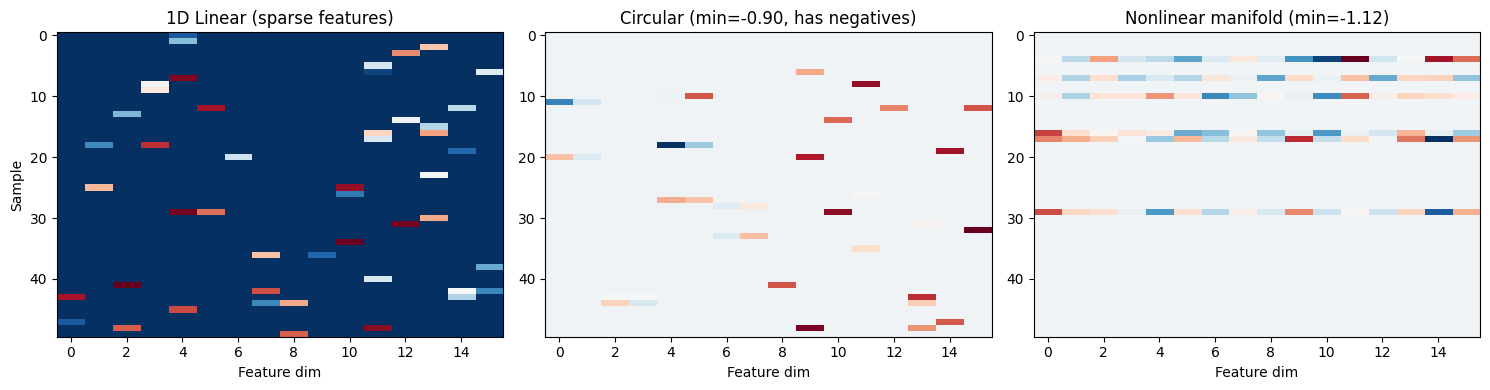

1D_linear           : range=[0.000, 1.000], frac_neg=0.000, PCA 90%=15d, 99%=16d
circular            : range=[-0.996, 1.000], frac_neg=0.012, PCA 90%=14d, 99%=16d
nonlinear           : range=[-1.343, 1.333], frac_neg=0.070, PCA 90%=8d, 99%=13d


In [2]:
def generate_1d_linear_data(n_samples, n_features, S=0.95):
    """Standard sparse features: each feature is a single direction.
    This is the Elhage et al. toy model setup."""
    mask = (torch.rand(n_samples, n_features) > S).float()
    values = torch.rand(n_samples, n_features)
    return (mask * values).to(device)


def generate_circular_data(n_samples, n_circles, n_extra_1d=0, S=0.95):
    """Circular features: each 'feature' lives on a 2D circle in embedding space.
    
    Models periodic/modular structure like days-of-week or months-of-year
    (Engels et al. 2024). Each circle uses 2 embedding dimensions.
    
    Returns:
        x: (n_samples, 2*n_circles + n_extra_1d) - the embedding-space representation
        angles: (n_samples, n_circles) - ground truth angles
        active: (n_samples, n_circles) - which circles are active
    """
    n_dim = 2 * n_circles + n_extra_1d
    x = torch.zeros(n_samples, n_dim, device=device)
    
    # Each circle: active with prob (1-S), then random angle + random intensity
    active = (torch.rand(n_samples, n_circles) > S).float().to(device)
    angles = (torch.rand(n_samples, n_circles) * 2 * np.pi).to(device)
    intensities = torch.rand(n_samples, n_circles).to(device)
    
    for c in range(n_circles):
        x[:, 2*c]     = active[:, c] * intensities[:, c] * torch.cos(angles[:, c])
        x[:, 2*c + 1] = active[:, c] * intensities[:, c] * torch.sin(angles[:, c])
    
    # Add standard 1D sparse features
    if n_extra_1d > 0:
        mask_1d = (torch.rand(n_samples, n_extra_1d) > S).float().to(device)
        vals_1d = torch.rand(n_samples, n_extra_1d).to(device)
        x[:, 2*n_circles:] = mask_1d * vals_1d
    
    return x, angles, active


def generate_nonlinear_manifold_data(n_samples, n_features, n_manifold_dims=2, 
                                      n_manifolds=3, S=0.95):
    """Features on genuinely nonlinear manifolds.
    
    Creates MULTIPLE independent nonlinear manifolds, each sparsely active.
    This ensures high effective dimensionality and actual compression pressure.
    
    Each manifold: n_manifold_dims latent params → nonlinear terms → projected
    to n_features dims. Multiple manifolds superpose in the same space.
    """
    x = torch.zeros(n_samples, n_features, device=device)
    
    for mf in range(n_manifolds):
        # Each manifold independently sparse
        active = (torch.rand(n_samples, 1) > S).float().to(device)
        t = torch.rand(n_samples, n_manifold_dims, device=device)
        
        terms = []
        for d in range(n_manifold_dims):
            terms.append(t[:, d])
        for d in range(n_manifold_dims):
            terms.append(t[:, d] ** 2)
        for d1 in range(n_manifold_dims):
            for d2 in range(d1+1, n_manifold_dims):
                terms.append(t[:, d1] * t[:, d2])
        for d in range(n_manifold_dims):
            terms.append(torch.sin(2 * np.pi * t[:, d]))
            terms.append(torch.cos(2 * np.pi * t[:, d]))
        
        n_terms = len(terms)
        term_stack = torch.stack(terms, dim=1)
        
        # Different random projection per manifold
        torch.manual_seed(42 + mf)
        proj = torch.randn(n_terms, n_features, device=device)
        proj = proj / proj.norm(dim=0, keepdim=True)
        
        manifold_embed = term_stack @ proj
        # Allow signed values — no ReLU clamping
        manifold_embed = manifold_embed / (manifold_embed.abs().max() + 1e-8)
        
        x = x + active * manifold_embed
    
    return x, t, active


# --- Model without final ReLU (needed for circular + nonlinear manifold data) ---
class FlexAutoencoder(nn.Module):
    """Autoencoder with optional final ReLU.
    Use final_relu=True for non-negative data (1D linear), 
    final_relu=False for signed data (circular, nonlinear manifold).
    """
    def __init__(self, n, m, l=1, tied_weights=True, final_relu=True):
        super().__init__()
        self.n = n
        self.m = m
        self.l = l
        self.tied_weights = tied_weights and (l == 1)
        self.final_relu = final_relu

        if self.tied_weights:
            self.encoder = nn.Linear(n, m, bias=False)
            self.decoder_bias = nn.Parameter(torch.zeros(n))
        else:
            encoder_layers = []
            for i in range(l - 1):
                encoder_layers.append(nn.Linear(n, n))
                encoder_layers.append(nn.ReLU())
            encoder_layers.append(nn.Linear(n, m))
            self.encoder = nn.Sequential(*encoder_layers)

            decoder_layers = [nn.Linear(m, n)]
            for i in range(l - 1):
                decoder_layers.append(nn.ReLU())
                decoder_layers.append(nn.Linear(n, n))
            if final_relu:
                decoder_layers.append(nn.ReLU())
            self.decoder = nn.Sequential(*decoder_layers)

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        if self.tied_weights:
            out = z @ self.encoder.weight + self.decoder_bias
            return nn.functional.relu(out) if self.final_relu else out
        return self.decoder(z)

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z), z


# Quick sanity check: visualize each data type
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

x_1d = generate_1d_linear_data(500, 16)
axes[0].imshow(x_1d[:50].cpu().numpy(), aspect='auto', cmap='RdBu_r')
axes[0].set_title('1D Linear (sparse features)')
axes[0].set_xlabel('Feature dim'); axes[0].set_ylabel('Sample')

x_circ, _, _ = generate_circular_data(500, 4, n_extra_1d=8)
axes[1].imshow(x_circ[:50].cpu().numpy(), aspect='auto', cmap='RdBu_r')
axes[1].set_title(f'Circular (min={x_circ.min():.2f}, has negatives)')
axes[1].set_xlabel('Feature dim')

x_nl, _, _ = generate_nonlinear_manifold_data(500, 16, n_manifold_dims=2, n_manifolds=3)
axes[2].imshow(x_nl[:50].cpu().numpy(), aspect='auto', cmap='RdBu_r')
axes[2].set_title(f'Nonlinear manifold (min={x_nl.min():.2f})')
axes[2].set_xlabel('Feature dim')

plt.tight_layout()
plt.show()

# Data statistics
for name, x in [('1D_linear', x_1d), ('circular', x_circ), ('nonlinear', x_nl)]:
    x_big = generate_1d_linear_data(10000, 16) if name == '1D_linear' else \
            generate_circular_data(10000, 4, n_extra_1d=8)[0] if name == 'circular' else \
            generate_nonlinear_manifold_data(10000, 16, n_manifold_dims=2, n_manifolds=3)[0]
    x_c = x_big - x_big.mean(0)
    svd = torch.linalg.svdvals(x_c)
    cum = (svd**2).cumsum(0) / (svd**2).sum()
    d90 = (cum < 0.9).sum().item() + 1
    d99 = (cum < 0.99).sum().item() + 1
    print(f"{name:20s}: range=[{x_big.min():.3f}, {x_big.max():.3f}], "
          f"frac_neg={( x_big<0).float().mean():.3f}, PCA 90%={d90}d, 99%={d99}d")

## Part 2: Taxonomy metrics

Four metrics to distinguish the three regimes:

In [3]:
def measure_encoding_linearity_custom(model, data_fn, n_samples=1000):
    """Measure how linear the learned encoding is, using the CORRECT data distribution.
    
    Unlike core.measure_encoding_linearity which always uses generate_sparse_data,
    this version accepts a data_fn so we evaluate on the same distribution the model
    was trained on.
    """
    model.eval()
    with torch.no_grad():
        x = data_fn(n_samples)
        z = model.encode(x)
        
        # Fit best linear approximation: z ≈ W @ x + b
        x_with_bias = torch.cat([x, torch.ones(n_samples, 1, device=device)], dim=1)
        W_linear = torch.linalg.lstsq(x_with_bias, z).solution
        z_linear = x_with_bias @ W_linear
        
        # Linearity score: fraction of z variance explained by linear fit
        z_var = z.var(dim=0).sum()
        residual_var = (z - z_linear).var(dim=0).sum()
        linearity_score = 1 - (residual_var / (z_var + 1e-8)).item()
        
        # Nonlinear gain: MSE improvement of full model over linear encoding
        x_recon_full, _ = model(x)
        x_recon_linear = model.decode(z_linear)
        
        mse_full = nn.functional.mse_loss(x_recon_full, x).item()
        mse_linear = nn.functional.mse_loss(x_recon_linear, x).item()
    
    return {
        'linearity_score': linearity_score,
        'mse_full': mse_full,
        'mse_linear': mse_linear,
        'nonlinear_gain': (mse_linear - mse_full) / (mse_linear + 1e-8),
    }


def measure_composition_additivity(model, data_fn, n_samples=500):
    """Test whether encoder satisfies composition-as-addition.
    
    The Anthropic (July 2024) definition of mathematical linearity:
    enc(x + y) ≈ enc(x) + enc(y)
    
    Returns relative violation: ||enc(x+y) - enc(x) - enc(y)|| / ||enc(x+y)||
    averaged over pairs. Values near 0 = mathematically linear.
    """
    model.eval()
    with torch.no_grad():
        x1 = data_fn(n_samples)
        x2 = data_fn(n_samples)
        
        z_sum = model.encode(x1 + x2)
        z1 = model.encode(x1)
        z2 = model.encode(x2)
        
        violation = (z_sum - z1 - z2).norm(dim=1)
        scale = z_sum.norm(dim=1) + 1e-8
        
        relative_violation = (violation / scale)
        # Filter out cases where z_sum is near zero (both inputs inactive)
        mask = scale > 0.01
        if mask.sum() > 10:
            relative_violation = relative_violation[mask]
        
    return {
        'additivity_violation_mean': relative_violation.mean().item(),
        'additivity_violation_median': relative_violation.median().item(),
        'additivity_violation_q90': relative_violation.quantile(0.9).item(),
    }


def measure_scaling_homogeneity(model, data_fn, n_samples=500):
    """Test whether encoder satisfies intensity-as-scaling.
    
    enc(t*x) ≈ t * enc(x) for t > 0
    
    Note: For bias-free ReLU networks, this is exactly satisfied (positive homogeneity).
    With biases, it will deviate.
    """
    model.eval()
    scales = [0.5, 1.5, 2.0, 3.0]
    violations = []
    
    with torch.no_grad():
        x = data_fn(n_samples)
        z_base = model.encode(x)
        
        for t in scales:
            z_scaled_input = model.encode(t * x)
            z_scaled_output = t * z_base
            
            diff = (z_scaled_input - z_scaled_output).norm(dim=1)
            ref = z_scaled_input.norm(dim=1) + 1e-8
            violations.append((diff / ref).mean().item())
    
    return {
        'homogeneity_violation_mean': np.mean(violations),
        'homogeneity_violations_by_scale': dict(zip(scales, violations)),
    }


def measure_feature_rank(model, data_fn, n_features, n_samples=200):
    """Measure effective rank of encoder Jacobian per input feature.
    
    For each input feature i, compute how many bottleneck dimensions
    are sensitive to it. 1D features → rank 1, multi-D → rank > 1.
    
    Uses the Jacobian rows corresponding to each input dimension.
    """
    model.eval()
    
    # Use the correct data distribution for Jacobian computation
    x_data = data_fn(n_samples)
    
    jacobians = []
    n_jac = min(n_samples, 50)
    for i in range(n_jac):
        xi = x_data[i:i+1].clone().detach().requires_grad_(True)
        zi = model.encode(xi)
        
        jac = torch.zeros(model.m, model.n, device=device)
        for j in range(model.m):
            if xi.grad is not None:
                xi.grad.zero_()
            zi[0, j].backward(retain_graph=True)
            jac[j] = xi.grad[0]
        jacobians.append(jac)
    
    jacobians = torch.stack(jacobians)  # (n_jac, m, n)
    
    # For each input feature, look at the column of the Jacobian
    # and measure how many bottleneck dims it activates
    per_feature_ranks = []
    for feat_idx in range(n_features):
        col = jacobians[:, :, feat_idx]
        svd = torch.linalg.svdvals(col)
        svd_norm = svd / (svd.sum() + 1e-10)
        eff_rank = torch.exp(-torch.sum(svd_norm * torch.log(svd_norm + 1e-10))).item()
        per_feature_ranks.append(eff_rank)
    
    # Overall Jacobian rank (averaged)
    mean_jac = jacobians.mean(dim=0)
    svd_overall = torch.linalg.svdvals(mean_jac)
    svd_norm_overall = svd_overall / (svd_overall.sum() + 1e-10)
    overall_rank = torch.exp(-torch.sum(svd_norm_overall * torch.log(svd_norm_overall + 1e-10))).item()
    
    # Jacobian variance across inputs (measures input-dependence = nonlinearity)
    jac_var = ((jacobians - mean_jac) ** 2).mean().item()
    
    return {
        'per_feature_ranks': per_feature_ranks,
        'mean_feature_rank': np.mean(per_feature_ranks),
        'max_feature_rank': np.max(per_feature_ranks),
        'overall_jacobian_rank': overall_rank,
        'jacobian_variance': jac_var,
    }


def measure_interpolation_curvature(model, data_fn, n_features, n_pairs=50, n_interp=20):
    """Measure curvature of paths in bottleneck space.
    
    For pairs of points from the data distribution, trace the interpolation path
    enc(t*x1 + (1-t)*x2) and compute arc/chord ratio.
    
    arc/chord = 1.0 → straight line (linear)
    arc/chord > 1.0 → curved path (nonlinear)
    """
    model.eval()
    
    ratios = []
    with torch.no_grad():
        # Use actual data points for interpolation (not just basis vectors)
        x_all = data_fn(n_pairs * 2)
        
        for p in range(n_pairs):
            x1 = x_all[2*p:2*p+1]
            x2 = x_all[2*p+1:2*p+2]
            
            # Interpolation path
            ts = torch.linspace(0, 1, n_interp, device=device)
            path_points = []
            for t in ts:
                x_interp = t * x1 + (1 - t) * x2
                z = model.encode(x_interp)
                path_points.append(z[0])
            
            path = torch.stack(path_points)  # (n_interp, m)
            
            # Arc length
            diffs = path[1:] - path[:-1]
            arc_length = diffs.norm(dim=1).sum().item()
            
            # Chord length
            chord_length = (path[-1] - path[0]).norm().item()
            
            if chord_length > 1e-8:
                ratios.append(arc_length / chord_length)
    
    return {
        'arc_chord_mean': np.mean(ratios) if ratios else float('nan'),
        'arc_chord_median': np.median(ratios) if ratios else float('nan'),
        'arc_chord_max': np.max(ratios) if ratios else float('nan'),
        'arc_chord_values': ratios,
    }


def full_taxonomy_measurement(model, data_fn, n_features):
    """Run all taxonomy metrics on a trained model.
    
    FIXED: Uses data_fn for ALL metrics so we evaluate on the correct
    data distribution (not always generate_sparse_data).
    """
    linearity = measure_encoding_linearity_custom(model, data_fn)
    additivity = measure_composition_additivity(model, data_fn)
    homogeneity = measure_scaling_homogeneity(model, data_fn)
    rank = measure_feature_rank(model, data_fn, n_features)
    curvature = measure_interpolation_curvature(model, data_fn, n_features)
    
    return {
        **linearity,
        **additivity,
        **homogeneity,
        **rank,
        **curvature,
    }

print("Metrics defined (FIXED: all metrics now use correct data distribution).")

Metrics defined (FIXED: all metrics now use correct data distribution).


## Part 3: Train autoencoders on each data type and measure

For each feature type, train autoencoders at varying depth `l` and compression `n/m`, then measure all taxonomy metrics.

In [4]:
def train_on_data(model, data_fn, n_steps=5000, batch_size=512, lr=1e-3):
    """Train autoencoder on data from data_fn."""
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_steps, eta_min=1e-5)
    losses = []
    
    for step in range(n_steps):
        x = data_fn(batch_size)
        optimizer.zero_grad()
        x_recon, z = model(x)
        loss = nn.functional.mse_loss(x_recon, x)
        loss.backward()
        optimizer.step()
        scheduler.step()
        losses.append(loss.item())
    
    return losses


# Configuration
n_features = 16
depths = [1, 2, 3]
compression_ratios = [0.25, 0.5, 0.75, 1.0]  # m/n
n_steps = 15000
n_seeds = 5

# Data generators with architecture info
data_configs = {
    '1D_linear': {
        'fn': lambda bs: generate_1d_linear_data(bs, n_features),
        'desc': 'Standard sparse 1D features',
        'final_relu': True,  # data is non-negative
    },
    'circular': {
        'fn': lambda bs: generate_circular_data(bs, n_circles=4, n_extra_1d=n_features-8)[0],
        'desc': '4 circular (2D) features + 8 extra 1D',
        'final_relu': False,  # cos/sin produce negative values!
    },
    'nonlinear_manifold': {
        'fn': lambda bs: generate_nonlinear_manifold_data(bs, n_features, n_manifold_dims=2, n_manifolds=3)[0],
        'desc': '3 independent nonlinear manifolds superposed in 16D',
        'final_relu': False,  # signed values from multiple manifolds
    },
}

total = len(data_configs) * len(depths) * len(compression_ratios) * n_seeds
print(f"Will sweep: {len(data_configs)} data types × {len(depths)} depths × {len(compression_ratios)} compressions × {n_seeds} seeds")
print(f"= {total} total experiments @ {n_steps} steps each")
print(f"\nFixes applied:")
print(f"  1. Cosine LR schedule for better convergence")
print(f"  2. No final ReLU for circular/manifold data — they have negative values")
print(f"  3. Multiple manifolds with signed output — creates actual compression pressure")
print(f"  4. CRITICAL: measure_encoding_linearity now uses correct data distribution")

Will sweep: 3 data types × 3 depths × 4 compressions × 5 seeds
= 180 total experiments @ 15000 steps each

Fixes applied:
  1. Cosine LR schedule for better convergence
  2. No final ReLU for circular/manifold data — they have negative values
  3. Multiple manifolds with signed output — creates actual compression pressure
  4. CRITICAL: measure_encoding_linearity now uses correct data distribution


In [5]:
import pandas as pd

all_results = []

total = len(data_configs) * len(depths) * len(compression_ratios) * n_seeds
pbar = tqdm(total=total, desc="Taxonomy sweep")

for data_name, data_cfg in data_configs.items():
    data_fn = data_cfg['fn']
    final_relu = data_cfg['final_relu']
    
    for l in depths:
        for ratio in compression_ratios:
            m = max(1, int(n_features * ratio))
            
            for seed in range(n_seeds):
                torch.manual_seed(seed)
                np.random.seed(seed)
                
                # Use FlexAutoencoder with correct final_relu for each data type
                model = FlexAutoencoder(
                    n_features, m, l=l, 
                    tied_weights=(l==1), 
                    final_relu=final_relu
                ).to(device)
                losses = train_on_data(model, data_fn, n_steps=n_steps)
                
                metrics = full_taxonomy_measurement(model, data_fn, n_features)
                
                result = {
                    'data_type': data_name,
                    'l': l,
                    'm': m,
                    'ratio': ratio,
                    'seed': seed,
                    'final_relu': final_relu,
                    'final_loss': np.mean(losses[-200:]),
                    'nonlinear_gain': metrics['nonlinear_gain'],
                    'linearity_score': metrics['linearity_score'],
                    'additivity_violation': metrics['additivity_violation_mean'],
                    'additivity_violation_q90': metrics['additivity_violation_q90'],
                    'homogeneity_violation': metrics['homogeneity_violation_mean'],
                    'mean_feature_rank': metrics['mean_feature_rank'],
                    'max_feature_rank': metrics['max_feature_rank'],
                    'jacobian_variance': metrics['jacobian_variance'],
                    'arc_chord_mean': metrics['arc_chord_mean'],
                    'arc_chord_max': metrics['arc_chord_max'],
                }
                all_results.append(result)
                
                pbar.update(1)
                pbar.set_postfix({
                    'data': data_name[:6],
                    'l': l,
                    'm': m,
                    'nl_gain': f"{metrics['nonlinear_gain']:.3f}",
                })

pbar.close()

df = pd.DataFrame(all_results)
print(f"\nCollected {len(df)} results")
print(f"\nQuick check — mean nonlinear gain by data type and depth:")
print(df.groupby(['data_type', 'l'])['nonlinear_gain'].mean().round(4).unstack())
df.head()

Taxonomy sweep:   0%|          | 0/180 [00:00<?, ?it/s]

Taxonomy sweep:   1%|          | 1/180 [00:02<08:00,  2.68s/it]

Taxonomy sweep:   1%|          | 1/180 [00:02<08:00,  2.68s/it, data=1D_lin, l=1, m=4, nl_gain=0.000]

Taxonomy sweep:   1%|          | 2/180 [00:04<06:55,  2.33s/it, data=1D_lin, l=1, m=4, nl_gain=0.000]

Taxonomy sweep:   1%|          | 2/180 [00:04<06:55,  2.33s/it, data=1D_lin, l=1, m=4, nl_gain=-0.000]

...

Taxonomy sweep: 100%|██████████| 180/180 [32:06<00:00, 23.02s/it, data=nonlin, l=3, m=16, nl_gain=0.163]

Taxonomy sweep: 100%|██████████| 180/180 [32:06<00:00, 23.02s/it, data=nonlin, l=3, m=16, nl_gain=0.338]

Taxonomy sweep: 100%|██████████| 180/180 [32:06<00:00, 10.70s/it, data=nonlin, l=3, m=16, nl_gain=0.338]


Collected 180 results

Quick check — mean nonlinear gain by data type and depth:
l                     1       2       3
data_type                              
1D_linear          -0.0  0.0255  0.0287
circular            0.0  0.0866  0.1344
nonlinear_manifold  0.0  0.0473  0.2689


,data_type,l,m,ratio,seed,final_relu,final_loss,nonlinear_gain,linearity_score,additivity_violation,additivity_violation_q90,homogeneity_violation,mean_feature_rank,max_feature_rank,jacobian_variance,arc_chord_mean,arc_chord_max
0,1D_linear,1,4,0.25,0,True,0.005241,0.000000e+00,1.0,1.297259e-08,4.738104e-08,1.255691e-08,1.000001,1.000002,3.217492e-15,1.0,1.0
1,1D_linear,1,4,0.25,1,True,0.005153,-1.748017e-07,1.0,1.454410e-08,4.917363e-08,1.321754e-08,1.000001,1.000002,2.785099e-15,1.0,1.0
2,1D_linear,1,4,0.25,2,True,0.005181,0.000000e+00,1.0,1.390796e-08,4.823249e-08,1.138277e-08,1.000001,1.000002,4.636267e-15,1.0,1.0
3,1D_linear,1,4,0.25,3,True,0.005102,-8.934066e-08,1.0,1.294022e-08,4.627119e-08,1.358290e-08,1.000001,1.000003,6.122124e-15,1.0,1.0
4,1D_linear,1,4,0.25,4,True,0.005169,0.000000e+00,1.0,1.459001e-08,5.010610e-08,1.239755e-08,1.000001,1.000002,4.934692e-15,1.0,1.0


## Part 4: Taxonomy phase diagrams

Visualize how each metric separates the three feature types across depth and compression.

In [6]:
# Aggregate over seeds
df_agg = df.groupby(['data_type', 'l', 'ratio']).agg({
    'nonlinear_gain': ['mean', 'std'],
    'additivity_violation': ['mean', 'std'],
    'homogeneity_violation': ['mean', 'std'],
    'mean_feature_rank': ['mean', 'std'],
    'arc_chord_mean': ['mean', 'std'],
    'jacobian_variance': ['mean', 'std'],
    'final_loss': ['mean', 'std'],
}).reset_index()

# Flatten column names
df_agg.columns = ['_'.join(col).strip('_') for col in df_agg.columns]

print("Aggregated results:")
df_agg[['data_type', 'l', 'ratio', 'nonlinear_gain_mean', 'additivity_violation_mean', 
         'mean_feature_rank_mean', 'arc_chord_mean_mean']].round(3)

Aggregated results:


,data_type,l,ratio,nonlinear_gain_mean,additivity_violation_mean,mean_feature_rank_mean,arc_chord_mean_mean
0,1D_linear,1,0.25,-0.000,0.000,1.000,1.000
1,1D_linear,1,0.50,0.000,0.000,1.000,1.000
2,1D_linear,1,0.75,-0.000,0.000,1.000,1.000
3,1D_linear,1,1.00,0.000,0.000,1.000,1.000
4,1D_linear,2,0.25,0.094,0.736,2.501,1.014
5,1D_linear,2,0.50,0.002,0.881,1.529,1.001
6,1D_linear,2,0.75,0.005,0.838,1.361,1.001
7,1D_linear,2,1.00,0.001,0.836,1.118,1.000
8,1D_linear,3,0.25,0.050,0.846,2.512,1.018
9,1D_linear,3,0.50,0.016,0.891,2.804,1.005


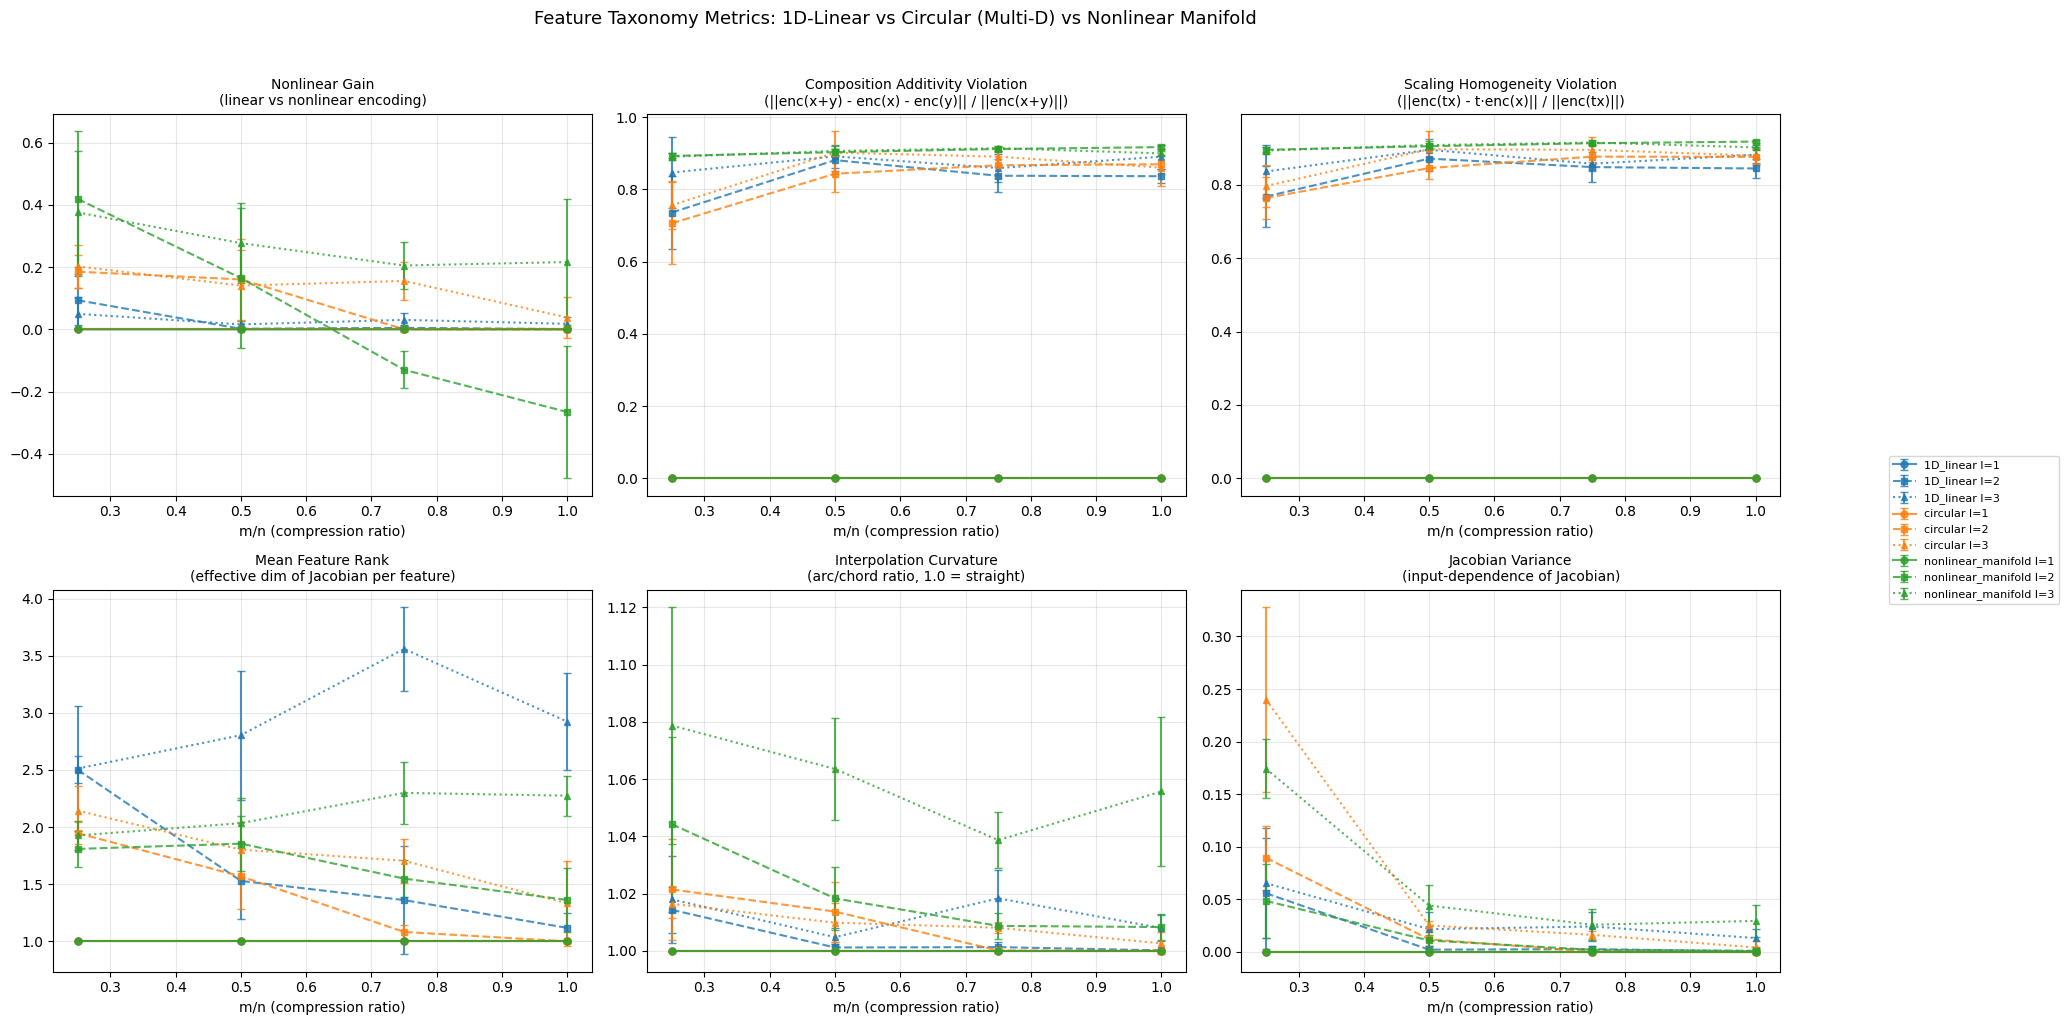

In [7]:
# Key metric comparisons across data types
metrics_to_plot = [
    ('nonlinear_gain', 'Nonlinear Gain\n(linear vs nonlinear encoding)'),
    ('additivity_violation', 'Composition Additivity Violation\n(||enc(x+y) - enc(x) - enc(y)|| / ||enc(x+y)||)'),
    ('homogeneity_violation', 'Scaling Homogeneity Violation\n(||enc(tx) - t·enc(x)|| / ||enc(tx)||)'),
    ('mean_feature_rank', 'Mean Feature Rank\n(effective dim of Jacobian per feature)'),
    ('arc_chord_mean', 'Interpolation Curvature\n(arc/chord ratio, 1.0 = straight)'),
    ('jacobian_variance', 'Jacobian Variance\n(input-dependence of Jacobian)'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

colors = {'1D_linear': 'C0', 'circular': 'C1', 'nonlinear_manifold': 'C2'}
markers = {1: 'o', 2: 's', 3: '^'}

for ax_idx, (metric, title) in enumerate(metrics_to_plot):
    ax = axes[ax_idx]
    
    for data_type in data_configs:
        for l in depths:
            mask = (df['data_type'] == data_type) & (df['l'] == l)
            sub = df[mask].groupby('ratio')[metric].agg(['mean', 'std']).reset_index()
            
            label = f"{data_type} l={l}"
            ax.errorbar(sub['ratio'], sub['mean'], yerr=sub['std'],
                       marker=markers[l], color=colors[data_type],
                       linestyle=['-', '--', ':'][l-1],
                       label=label, capsize=3, markersize=5, alpha=0.8)
    
    ax.set_xlabel('m/n (compression ratio)')
    ax.set_title(title, fontsize=10)
    ax.grid(True, alpha=0.3)

# Single legend for all subplots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.15, 0.5), fontsize=8)

plt.suptitle('Feature Taxonomy Metrics: 1D-Linear vs Circular (Multi-D) vs Nonlinear Manifold', 
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

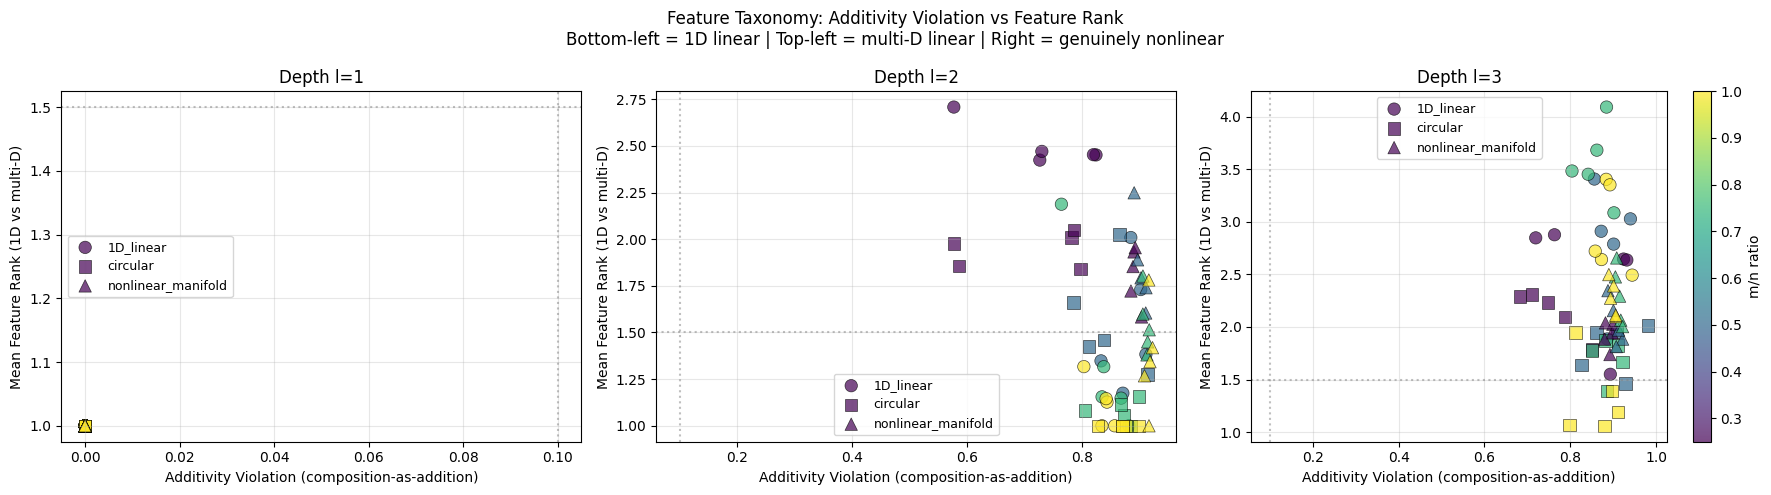

In [8]:
# Scatter plot: the two key axes that separate all three regimes
# X = additivity violation (separates mathematically-linear from nonlinear)
# Y = mean feature rank (separates 1D from multi-D)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax_idx, l in enumerate(depths):
    ax = axes[ax_idx]
    
    for data_type in data_configs:
        mask = (df['data_type'] == data_type) & (df['l'] == l)
        sub = df[mask]
        
        scatter = ax.scatter(
            sub['additivity_violation'], 
            sub['mean_feature_rank'],
            c=sub['ratio'],
            marker={'1D_linear': 'o', 'circular': 's', 'nonlinear_manifold': '^'}[data_type],
            s=80, alpha=0.7, edgecolors='k', linewidths=0.5,
            label=data_type,
            cmap='viridis',
        )
    
    ax.set_xlabel('Additivity Violation (composition-as-addition)')
    ax.set_ylabel('Mean Feature Rank (1D vs multi-D)')
    ax.set_title(f'Depth l={l}')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Annotate quadrants
    ax.axhline(y=1.5, color='gray', linestyle=':', alpha=0.5)
    ax.axvline(x=0.1, color='gray', linestyle=':', alpha=0.5)

plt.colorbar(scatter, ax=axes[-1], label='m/n ratio')
plt.suptitle('Feature Taxonomy: Additivity Violation vs Feature Rank\n'
             'Bottom-left = 1D linear | Top-left = multi-D linear | Right = genuinely nonlinear',
             fontsize=12)
plt.tight_layout()
plt.show()

## Part 5: Does depth unlock nonlinearity differently for each feature type?

The key question for connecting to the Tegmark paper: when the ground-truth features are circular (multi-D linear), does a deep autoencoder learn a genuinely nonlinear encoding, or does it stay mathematically linear?

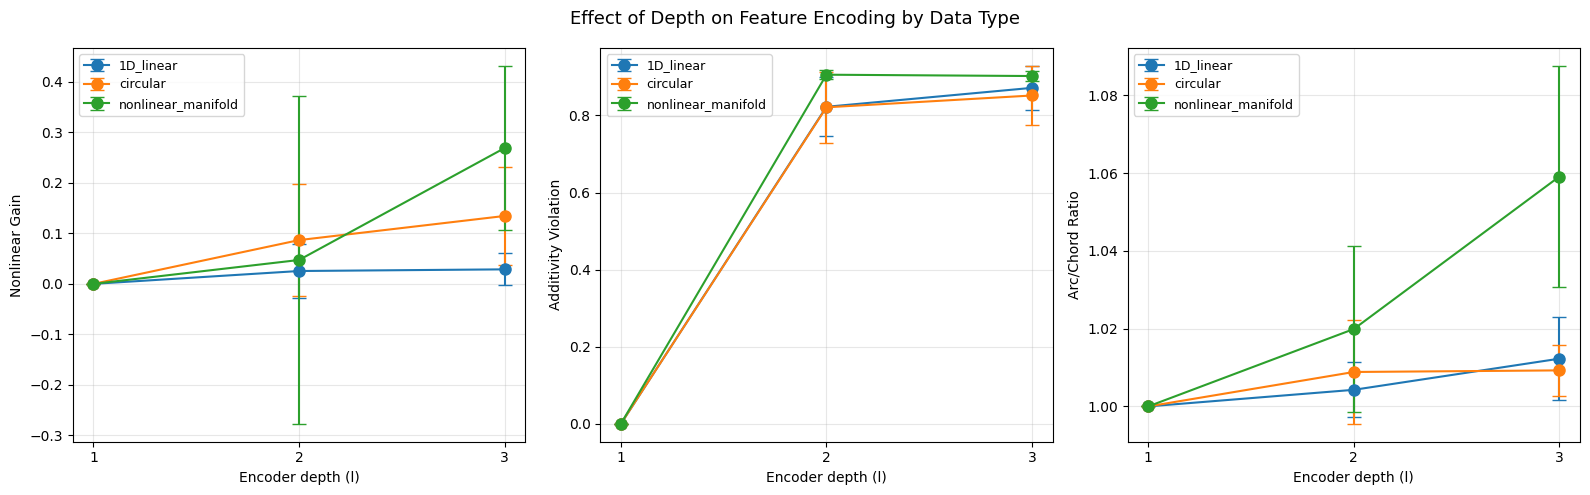

In [9]:
# Focus on the depth effect: how do metrics change with l for each data type?
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

key_metrics = [
    ('nonlinear_gain', 'Nonlinear Gain'),
    ('additivity_violation', 'Additivity Violation'),
    ('arc_chord_mean', 'Arc/Chord Ratio'),
]

for ax_idx, (metric, ylabel) in enumerate(key_metrics):
    ax = axes[ax_idx]
    
    # Average over compression ratios to focus on depth effect
    for data_type in data_configs:
        mask = df['data_type'] == data_type
        sub = df[mask].groupby('l')[metric].agg(['mean', 'std']).reset_index()
        
        ax.errorbar(sub['l'], sub['mean'], yerr=sub['std'],
                   marker='o', label=data_type, capsize=5, markersize=8)
    
    ax.set_xlabel('Encoder depth (l)')
    ax.set_ylabel(ylabel)
    ax.set_xticks(depths)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Effect of Depth on Feature Encoding by Data Type', fontsize=13)
plt.tight_layout()
plt.show()

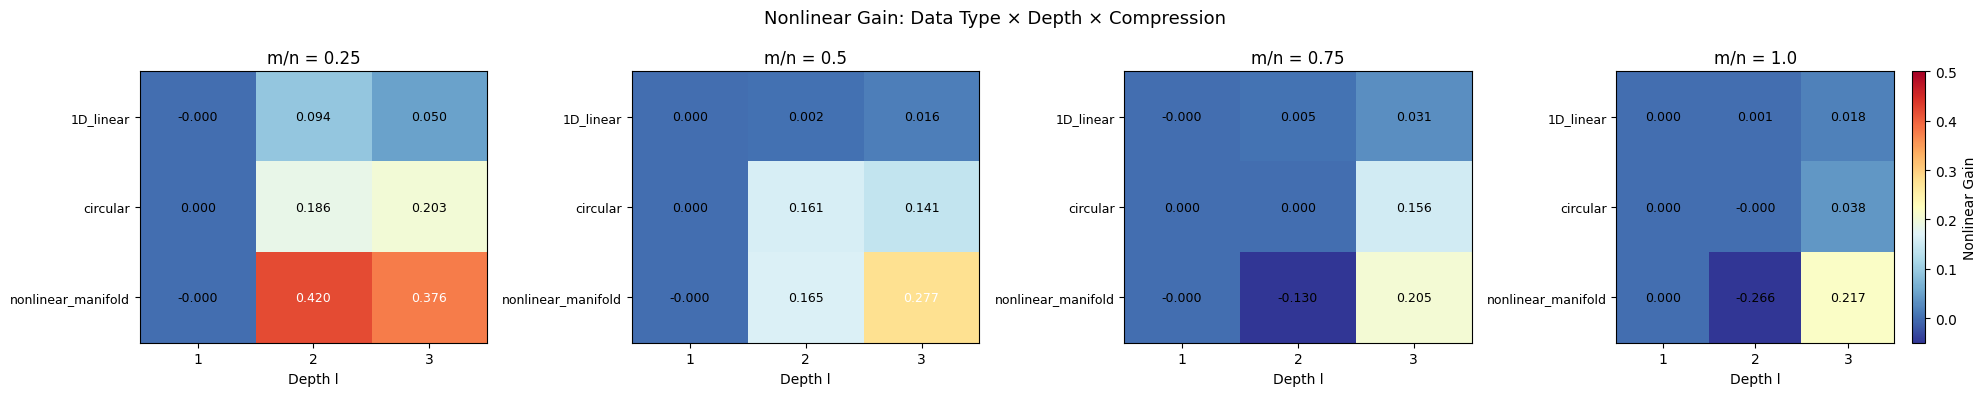

In [10]:
# Heatmaps: nonlinear gain as a function of (data_type, l) for each compression
fig, axes = plt.subplots(1, len(compression_ratios), figsize=(5*len(compression_ratios), 4))

for ax_idx, ratio in enumerate(compression_ratios):
    ax = axes[ax_idx]
    
    pivot = df[df['ratio'] == ratio].groupby(['data_type', 'l'])['nonlinear_gain'].mean().reset_index()
    pivot_table = pivot.pivot(index='data_type', columns='l', values='nonlinear_gain')
    
    im = ax.imshow(pivot_table.values, cmap='RdYlBu_r', aspect='auto', vmin=-0.05, vmax=0.5)
    ax.set_xticks(range(len(depths)))
    ax.set_xticklabels(depths)
    ax.set_yticks(range(len(pivot_table.index)))
    ax.set_yticklabels(pivot_table.index, fontsize=9)
    ax.set_xlabel('Depth l')
    ax.set_title(f'm/n = {ratio}')
    
    # Annotate cells
    for i in range(pivot_table.shape[0]):
        for j in range(pivot_table.shape[1]):
            val = pivot_table.values[i, j]
            ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=9,
                   color='white' if val > 0.25 else 'black')

plt.colorbar(im, ax=axes[-1], label='Nonlinear Gain')
plt.suptitle('Nonlinear Gain: Data Type × Depth × Compression', fontsize=13)
plt.tight_layout()
plt.show()

## Part 6: Can a linear SAE recover multi-D features, or does it tile them?

Train a deep autoencoder on circular data, then fit a linear SAE on its bottleneck representations. Check whether the SAE recovers the true 2D structure or tiles it with many 1D latents (per the feature manifold scaling paper).

In [11]:
class LinearSAE(nn.Module):
    """Standard linear sparse autoencoder for comparison."""
    def __init__(self, input_dim, dict_size):
        super().__init__()
        self.encoder = nn.Linear(input_dim, dict_size)
        self.decoder = nn.Linear(dict_size, input_dim, bias=True)
    
    def forward(self, x):
        h = torch.relu(self.encoder(x))
        x_recon = self.decoder(h)
        return x_recon, h


def train_sae_on_bottleneck(autoencoder, data_fn, sae_dict_size=64, 
                             n_steps=5000, batch_size=512, l1_coeff=1e-3):
    """Train a linear SAE on the bottleneck representations of a trained autoencoder."""
    autoencoder.eval()
    
    sae = LinearSAE(autoencoder.m, sae_dict_size).to(device)
    optimizer = optim.Adam(sae.parameters(), lr=1e-3)
    
    losses = []
    for step in range(n_steps):
        x = data_fn(batch_size)
        with torch.no_grad():
            z = autoencoder.encode(x)
        
        z_recon, h = sae(z)
        recon_loss = nn.functional.mse_loss(z_recon, z)
        sparsity_loss = l1_coeff * h.abs().mean()
        loss = recon_loss + sparsity_loss
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    
    with torch.no_grad():
        x_test = data_fn(1000)
        z_test = autoencoder.encode(x_test)
        z_recon_test, h_test = sae(z_test)
        
        n_active = (h_test > 0.01).float().sum(dim=1).mean().item()
        recon_quality = 1 - nn.functional.mse_loss(z_recon_test, z_test).item() / z_test.var().item()
        
        W_dec = sae.decoder.weight.data
        W_dec_norm = W_dec / (W_dec.norm(dim=0, keepdim=True) + 1e-8)
        cos_sim = (W_dec_norm.T @ W_dec_norm).cpu().numpy()
    
    return {
        'sae': sae,
        'losses': losses,
        'mean_active_features': n_active,
        'recon_quality': recon_quality,
        'cos_sim_matrix': cos_sim,
    }


# Train deep autoencoder on circular data (no final ReLU!), then SAE on its bottleneck
print("Training deep autoencoder on circular data (no final ReLU)...")
n_circ = 16
m_circ = 8
l_circ = 3

circ_data_fn = lambda bs: generate_circular_data(bs, n_circles=4, n_extra_1d=n_circ-8)[0]

torch.manual_seed(0)
ae_circ = FlexAutoencoder(n_circ, m_circ, l=l_circ, tied_weights=False, final_relu=False).to(device)
ae_losses = train_on_data(ae_circ, circ_data_fn, n_steps=15000)
print(f"Autoencoder final loss: {np.mean(ae_losses[-200:]):.6f}")

print("\nTraining linear SAE on bottleneck...")
sae_results = train_sae_on_bottleneck(ae_circ, circ_data_fn, sae_dict_size=64)
print(f"SAE recon quality: {sae_results['recon_quality']:.4f}")
print(f"Mean active SAE features per input: {sae_results['mean_active_features']:.1f}")

Training deep autoencoder on circular data (no final ReLU)...


Autoencoder final loss: 0.001351

Training linear SAE on bottleneck...


SAE recon quality: 1.0000
Mean active SAE features per input: 50.7


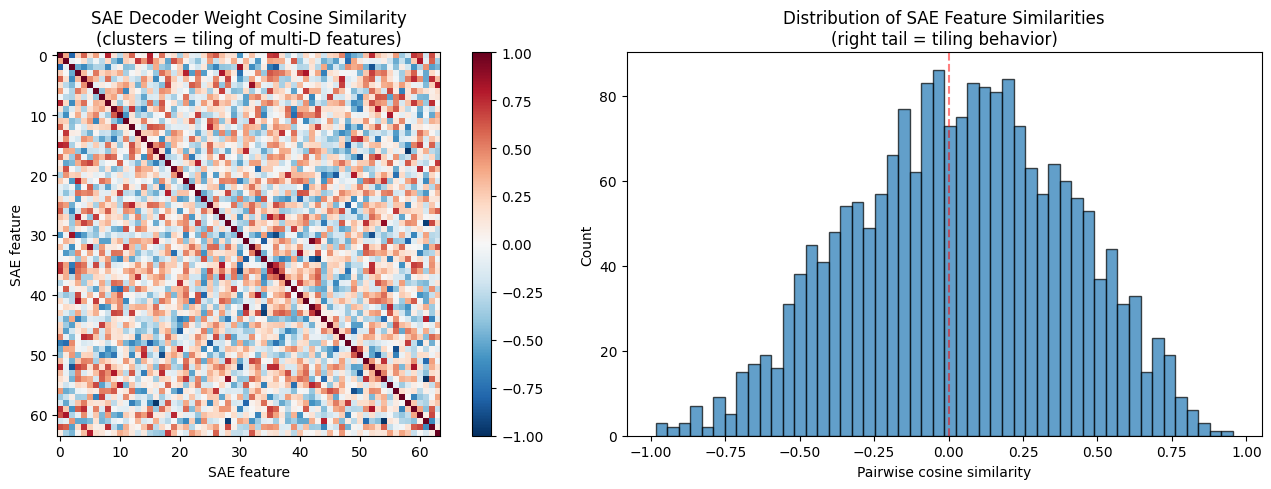


Highly similar pairs (|cos| > 0.5): 368/2016 (18.3%)
This suggests tiling behavior


In [12]:
# Visualize SAE decoder weight similarity — clustered features = tiling of manifolds
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cosine similarity matrix
ax = axes[0]
cos_sim = sae_results['cos_sim_matrix']
im = ax.imshow(cos_sim, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_title('SAE Decoder Weight Cosine Similarity\n(clusters = tiling of multi-D features)')
ax.set_xlabel('SAE feature')
ax.set_ylabel('SAE feature')
plt.colorbar(im, ax=ax)

# Distribution of pairwise similarities
ax = axes[1]
upper_tri = cos_sim[np.triu_indices_from(cos_sim, k=1)]
ax.hist(upper_tri, bins=50, edgecolor='black', alpha=0.7)
ax.axvline(x=0, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Pairwise cosine similarity')
ax.set_ylabel('Count')
ax.set_title('Distribution of SAE Feature Similarities\n(right tail = tiling behavior)')

plt.tight_layout()
plt.show()

# Quantify: what fraction of SAE features are highly similar to another?
n_highly_similar = (np.abs(upper_tri) > 0.5).sum()
n_total_pairs = len(upper_tri)
print(f"\nHighly similar pairs (|cos| > 0.5): {n_highly_similar}/{n_total_pairs} ({100*n_highly_similar/n_total_pairs:.1f}%)")
print(f"This suggests {'tiling' if n_highly_similar/n_total_pairs > 0.1 else 'distinct'} behavior")

## Part 7: Summary table — which metrics separate which regimes?

The goal: a clean mapping from observable metrics to feature taxonomy.

In [13]:
# Summary: mean metrics by data type (averaged over all configs)
summary = df.groupby('data_type').agg({
    'nonlinear_gain': 'mean',
    'additivity_violation': 'mean',
    'homogeneity_violation': 'mean',
    'mean_feature_rank': 'mean',
    'arc_chord_mean': 'mean',
    'jacobian_variance': 'mean',
}).round(4)

print("="*80)
print("SUMMARY: Mean metrics by ground-truth feature type")
print("="*80)
print(summary.to_string())
print()

# Which metrics actually discriminate?
print("\nDiscrimination analysis:")
for metric in ['nonlinear_gain', 'additivity_violation', 'homogeneity_violation', 
               'mean_feature_rank', 'arc_chord_mean', 'jacobian_variance']:
    vals = summary[metric]
    spread = vals.max() - vals.min()
    mean_val = vals.mean()
    cv = spread / (mean_val + 1e-8)
    print(f"  {metric:30s}: range [{vals.min():.4f}, {vals.max():.4f}], "
          f"spread/mean = {cv:.2f} {'*** GOOD ***' if cv > 0.5 else ''}")

SUMMARY: Mean metrics by ground-truth feature type
                    nonlinear_gain  additivity_violation  homogeneity_violation  mean_feature_rank  arc_chord_mean  jacobian_variance
data_type                                                                                                                            
1D_linear                   0.0181                0.5648                 0.5667             1.8589          1.0055             0.0154
circular                    0.0737                0.5577                 0.5690             1.3818          1.0060             0.0322
nonlinear_manifold          0.1054                0.6027                 0.6039             1.5925          1.0264             0.0280


Discrimination analysis:
  nonlinear_gain                : range [0.0181, 0.1054], spread/mean = 1.33 *** GOOD ***
  additivity_violation          : range [0.5577, 0.6027], spread/mean = 0.08 
  homogeneity_violation         : range [0.5667, 0.6039], spread/mean = 0.06 
  mean

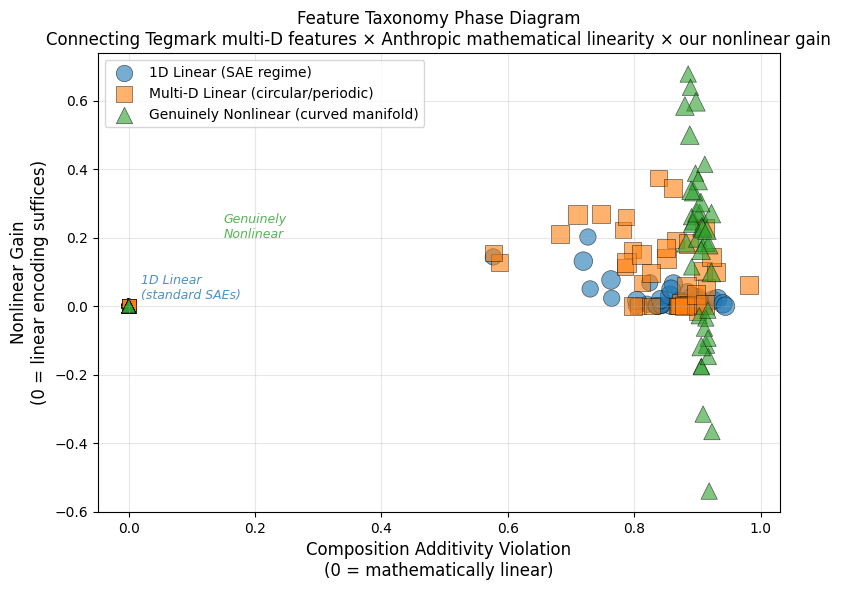

In [14]:
# Final 2D taxonomy plot: the "phase diagram" of feature types
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

marker_map = {'1D_linear': 'o', 'circular': 's', 'nonlinear_manifold': '^'}
color_map = {'1D_linear': 'C0', 'circular': 'C1', 'nonlinear_manifold': 'C2'}
label_map = {
    '1D_linear': '1D Linear (SAE regime)',
    'circular': 'Multi-D Linear (circular/periodic)',
    'nonlinear_manifold': 'Genuinely Nonlinear (curved manifold)',
}

for data_type in data_configs:
    mask = df['data_type'] == data_type
    sub = df[mask]
    
    ax.scatter(
        sub['additivity_violation'],
        sub['nonlinear_gain'],
        marker=marker_map[data_type],
        c=color_map[data_type],
        s=60 + 40 * sub['l'],  # Size by depth
        alpha=0.6,
        edgecolors='k',
        linewidths=0.5,
        label=label_map[data_type],
    )

ax.set_xlabel('Composition Additivity Violation\n(0 = mathematically linear)', fontsize=12)
ax.set_ylabel('Nonlinear Gain\n(0 = linear encoding suffices)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_title('Feature Taxonomy Phase Diagram\n'
             'Connecting Tegmark multi-D features × Anthropic mathematical linearity × our nonlinear gain',
             fontsize=12)

# Annotate regions
ax.annotate('1D Linear\n(standard SAEs)', xy=(0.02, 0.02), fontsize=9, 
           fontstyle='italic', color='C0', alpha=0.8)
ax.annotate('Genuinely\nNonlinear', xy=(0.15, 0.2), fontsize=9,
           fontstyle='italic', color='C2', alpha=0.8)

plt.tight_layout()
plt.show()

## Interpretation & Next Steps

### What we measured
- **Nonlinear gain**: Separates regimes where the autoencoder *needs* nonlinearity from those where linear suffices
- **Additivity violation**: Tests the Anthropic (July 2024) definition of "mathematically linear" directly
- **Homogeneity violation**: Tests intensity-as-scaling (exact for bias-free ReLU networks per our positive homogeneity proof)
- **Feature rank**: Distinguishes 1D features (SAE-compatible) from multi-D features (need subspace methods)
- **Arc/chord curvature**: Geometric signature of genuinely nonlinear encoding

### Connection to the literature

| Paper | What they propose | Our toy-model analog | Metric that detects it |
|-------|-------------------|---------------------|----------------------|
| **Engels et al. (Tegmark)** | Irreducible 2D circular features | `circular` data generator | `mean_feature_rank > 1` |
| **Shafran et al. "Directions→Regions"** | MFA with local covariance replaces SAE directions | Deep AE on circular data | `jacobian_variance` (input-dependent Jacobian = local structure) |
| **Luo et al. diffusion meta-model** | Assumption-free generative model of activations | Deep AE with nonlinear gain > 0 | `nonlinear_gain`, `additivity_violation` |
| **SpaDE (Hindupur et al.)** | SAE architecture determines discoverable concepts | SAE-on-bottleneck tiling experiment | Decoder weight clustering, `mean_active_features` |
| **Circuits Updates July 2024** | "Mathematically linear" = additivity + scaling | All three data types | `additivity_violation`, `homogeneity_violation` |
| **Engels & Michaud manifold scaling** | SAEs tile manifolds with 1D latents | Part 6 SAE-on-bottleneck | Cosine similarity clustering of SAE decoder weights |

### The three-way taxonomy in practice
- **Standard SAEs** (Cunningham et al.) work in the 1D-linear regime (bottom-left of phase diagram)
- **MFA / subspace methods** (Shafran et al.) extend to multi-D-linear (top-left) — still additive composition, but features span subspaces
- **Diffusion / nonlinear methods** (Luo et al., SpaDE) are needed for genuinely nonlinear features (right side) — composition ≠ addition

### Open questions
1. Do real LLM features populate all three regimes, or is one dominant? Shafran et al. and Luo et al. both show gains over SAEs, suggesting non-1D features exist in practice
2. Does depth `l` let the autoencoder discover multi-D structure that `l=1` misses, even when the ground truth is multi-D linear?
3. Can we design a metric that distinguishes "the autoencoder chose nonlinear" from "the autoencoder needed nonlinear"?
4. The Shafran MFA approach assumes local Gaussianity — is this a weaker assumption than SAE sparsity, or just a different one? Our framework could test this by generating data that violates each assumption differently
5. The Luo diffusion approach makes no structural assumptions but is expensive. Is there a sweet spot between SAE (cheap, strong assumptions) and diffusion (expensive, no assumptions)?